number of pulsars 2014
Done in 1.7s


<IPython.core.display.Javascript object>


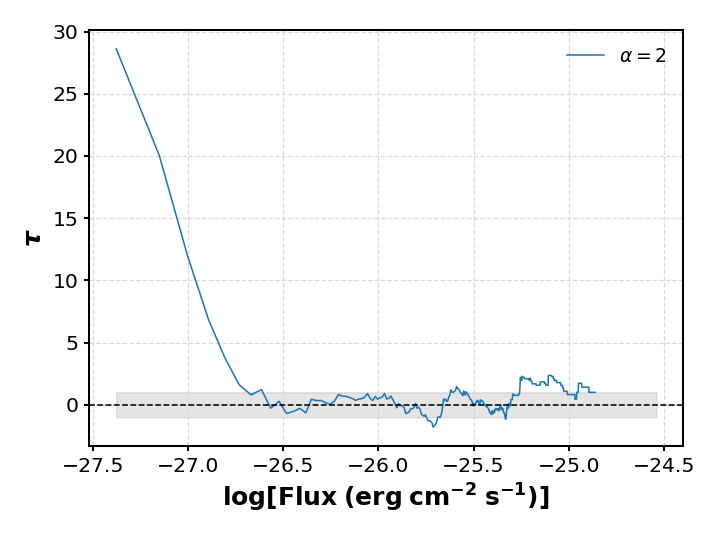

In [3]:
#code for fig 3,10 in manuscript 
%reset -f
%matplotlib notebook
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import sys
sys.path.append('path to psrpoppy')
import matplotlib as mpl

#GLOBAL STYLE SETTINGS
mpl.rcParams.update({
    "font.size": 14,                
    "axes.labelweight": "bold",     
    "axes.titlesize": 16,           
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,          
    "lines.linewidth": 1,         
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})



sys.modules['population'] = real_population
filename='PMSURV.results'




#df_smr = pd.read_excel("/home/sanjith/PsrPopPy/df_smr.xlsx")


with open(filename, 'rb') as f:
    pop = pickle.load(f)

# Extract data
fluxes = np.array([psr.s_1400() for psr in pop.population])*10**-26
distances = np.array([psr.dtrue for psr in pop.population])*1000  
snr=np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)

# Build DataFrame (read-only)
df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})
#df=df[df["snr"] >= 9]
#plt.figure(figsize=(8,4),dpi=1000)

#selecting only positive snr's 


#df = pd.concat([df, df_smr], ignore_index=True) #adding smeared pulsars  to the dataset

#flux_cut=10**((-2-1.734)/1.06)
#print("log_flux_cut",np.log10(flux_cut))


df['Flux_log'] = np.log10(df['Flux'])
df['Dist_log'] = np.log10(df['Distance'])

def compute_LogLth(D_array, flux_thresh, alpha):
    """Compute log10(flux_thresh * D^alpha)"""
    return np.log10(flux_thresh)+ alpha * np.log10(D_array)

@njit
def compute_tau_numba(D_logs, Lprime_logs, thresh, alpha):
    n = len(D_logs)
    N_a = np.zeros(n, dtype=np.int64)
    R_a = np.zeros(n, dtype=np.int64)
    E_a = np.zeros(n)
    V_a = np.zeros(n)

    for i in range(n):
        Di = D_logs[i]
        Li = Lprime_logs[i]
        L_thi = np.log10(thresh * (10 ** Di) ** alpha)
        N_count = 0
        R_count = 0
        for j in range(n):
            D = D_logs[j]
            L = Lprime_logs[j]
            if (D <= Di) and (L >= L_thi):
                N_count += 1
                if Li >= L:
                    R_count += 1
        N_a[i] = N_count
        R_a[i] = R_count
        E_a[i] = 0.5 * (N_count + 1)
        V_a[i] = (N_count ** 2 - 1) / 12 if N_count > 0 else 0.0
        if N_count <= 0:
            print("[WARN]", "i=", i, "Di=", Di, "Li=", Li, "L_thi=", L_thi, "N_count=", N_count)

    numerator = np.sum(R_a - E_a)
    denominator = np.sqrt(np.sum(V_a))
    if N_count <= 0:
            print("[WARN]", "i=", i, "Di=", Di, "Li=", Li, "L_thi=", L_thi, "N_count=", N_count)
    return numerator / denominator if denominator != 0 else np.nan

def compute_tau_for_alpha(alpha_thresh):
    alpha, thresh = alpha_thresh

    
    LogLthA = compute_LogLth(df['Distance'].values, thresh, alpha)

    Lprime_Log = df['Flux_log'].values + alpha * df['Dist_log'].values #computatin of lprime

    
    mask = Lprime_Log >= LogLthA
    D_logs = df['Dist_log'].values[mask] #making 
    Lprime_logs = Lprime_Log[mask]

    if len(D_logs) == 0:
        print(f"[WARN] alpha={alpha:.2f}, thresh={thresh:.2e}: 0 points passed mask")
        return alpha, np.nan

    tau = compute_tau_numba(D_logs, Lprime_logs, thresh, alpha)
    return alpha, tau

if __name__ == '__main__':
    #plt.figure(figsize=(8,6))
   # quantiles =                                                               #no flux threshold removal 
    thresholds = np.linspace(np.min(df["Flux"]), np.max(df["Flux"]),1000)
    alphas =[2]
    #print(f"\nComputing for quantile={q:.2f}, flux threshold={thresh:.2f}")
    start = time.time()
    for alpha in alphas:
        alpha_thresh_list = [(alpha, thresh) for thresh  in thresholds]

        # Limit number of parallel processes to save RAM:
        with multiprocessing.Pool(processes=4) as pool:
            results = pool.map(compute_tau_for_alpha, alpha_thresh_list)

        # Sort results by alpha
        #results.sort(key=lambda x: x[0])

        taus = [tau for alpha, tau in results]
        
        

        print(f"Done in {time.time() - start:.1f}s")
        plt.plot(np.log10(thresholds),taus, label=f"$\\alpha={alpha}$")

plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'$\mathbf{log [Flux\;(erg\;cm^{-2}\;s^{-1})]}$', fontsize=16)
plt.ylabel(r'$\boldsymbol{\tau}$', fontsize=16)


plt.fill_between(np.log10(thresholds), -1, 1, color='gray', alpha=0.2)


plt.legend(frameon=False, loc="best", facecolor='white', framealpha=0.9, edgecolor='black')
plt.grid(zorder=1)
plt.tight_layout()
#plt.savefig("path/efron_petrosian_tau_vs_threshold_2000_ne2001_lfl06_default.pdf", dpi=1000, bbox_inches="tight")
plt.show()

